In [1]:
# Load the libraries
import os
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedGroupKFold

In [2]:
# Load the source CSV from FLOWGUARD_CSV or this project's notebooks folder
current = Path.cwd()
project = current.parent if current.name == "notebooks" else current
if not (project / "notebooks").is_dir():
    raise FileNotFoundError("Run this notebook from the project or notebooks folder")
default_csv = project / "notebooks" / "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv"
csv_path = Path(os.environ.get("FLOWGUARD_CSV", default_csv)).expanduser()
if not csv_path.is_file():
    raise FileNotFoundError(f"Source CSV not found: {csv_path}")
df = pd.read_csv(csv_path, low_memory=False)
df.columns = df.columns.str.strip()
print("Loaded:", csv_path.resolve(), "Rows:", len(df))

Loaded: C:\Users\joy\Downloads\Jupyter\FlowGuard-69-Release\notebooks\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv Rows: 225745


In [3]:
# Load the CSV
data = df.copy()
original_rows = len(data)
print("Rows:", original_rows, "Columns:", len(data.columns))
display(data.head())

Rows: 225745 Columns: 85


,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,192.168.10.5-104.16.207.165-54865-443-6,104.16.207.165,443,192.168.10.5,54865,6,7/7/2017 3:30,3,2,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,192.168.10.5-104.16.28.216-55054-80-6,104.16.28.216,80,192.168.10.5,55054,6,7/7/2017 3:30,109,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,192.168.10.5-104.16.28.216-55055-80-6,104.16.28.216,80,192.168.10.5,55055,6,7/7/2017 3:30,52,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,192.168.10.16-104.17.241.25-46236-443-6,104.17.241.25,443,192.168.10.16,46236,6,7/7/2017 3:30,34,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,192.168.10.5-104.19.196.102-54863-443-6,104.19.196.102,443,192.168.10.5,54863,6,7/7/2017 3:30,3,2,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [4]:
print("Label distribution:")
print(data["Label"].value_counts().to_dict())

print("\nUnique labels:")
print(df["Label"].unique())

Label distribution:
{'DDoS': 128027, 'BENIGN': 97718}

Unique labels:
<StringArray>
['BENIGN', 'DDoS']
Length: 2, dtype: str


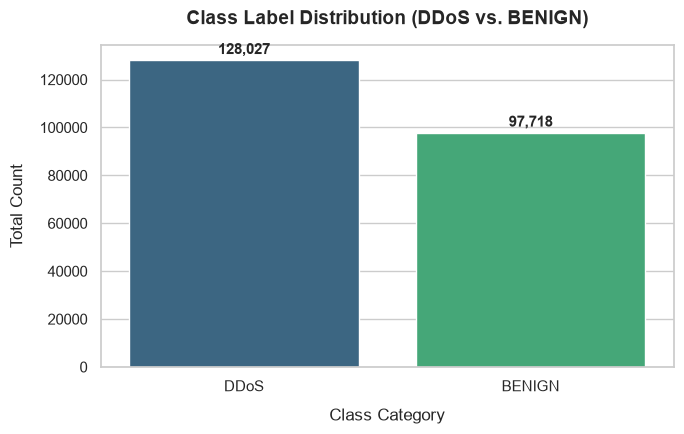

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 4.5))

label_counts = data["Label"].value_counts()

sns.barplot(x=label_counts.index, y=label_counts.values, hue=label_counts.index, palette="viridis", legend=False)

plt.title("Class Label Distribution (DDoS vs. BENIGN)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Class Category", fontsize=12, labelpad=10)
plt.ylabel("Total Count", fontsize=12, labelpad=10)


for i, count in enumerate(label_counts.values):
    plt.text(i, count + (max(label_counts.values) * 0.01), f"{count:,}", 
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [6]:
print("Column names:", data.columns.tolist())
print("")

print("Missing values:", int(data.isna().sum().sum()))
print("Infinite values:", int(np.isinf(data.select_dtypes(include=np.number)).sum().sum()))
print("Duplicate rows:", int(data.duplicated().sum()))

Column names: ['Flow ID', 'Source IP', 'Source Port', 'Destination IP', 'Destination Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag

In [7]:
#Removes Unnecessary Spaces
data.columns = data.columns.str.strip()
data["Label"] = data["Label"].astype(str).str.strip()
data = data.replace([np.inf, -np.inf], np.nan)
print("Labels:", data["Label"].value_counts().to_dict())

Labels: {'DDoS': 128027, 'BENIGN': 97718}


In [8]:
# Keep BENIGN and DDoS; remove duplicate rows
data = data.loc[data["Label"].isin(["BENIGN", "DDoS"])]
data = data.drop_duplicates().reset_index(drop=True)
print("Before:", original_rows, "After:", len(data))

Before: 225745 After: 225743


In [9]:
# Remove identifiers and Destination Port
excluded = [
    "Label", "Flow ID", "Source IP", "Destination IP",
    "Timestamp", "Destination Port",
]
model_data = data.drop(columns=excluded)
print("Remaining columns:", len(model_data.columns))

Remaining columns: 79


In [10]:
# Keep numerical flow measurements
model_data = model_data.select_dtypes(include=np.number)
print("Numerical columns:", len(model_data.columns))
print("Missing values after cleaning:", int(model_data.isna().sum().sum()))

Numerical columns: 79
Missing values after cleaning: 68


In [11]:
# Encode BENIGN and DDoS
labels = data["Label"].map({"BENIGN": 0, "DDoS": 1})
print("BENIGN = 0, DDoS = 1")
print("Class counts:", labels.value_counts().to_dict())

BENIGN = 0, DDoS = 1
Class counts: {1: 128027, 0: 97716}


In [12]:
# Group nearby traffic by time
time_blocks = pd.to_datetime(
    data["Timestamp"], format="%m/%d/%Y %H:%M", errors="raise"
).dt.floor("2min")
print("Two-minute groups:", time_blocks.nunique())

Two-minute groups: 47


In [13]:
# Hold out test groups
outer = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
trainval_rows, test_rows = next(
    outer.split(model_data, labels, groups=time_blocks)
)
assert set(time_blocks.iloc[trainval_rows]).isdisjoint(set(time_blocks.iloc[test_rows]))
print("Development rows:", len(trainval_rows))
print("Test rows:", len(test_rows))

Development rows: 180176
Test rows: 45567


In [14]:
# Remove columns that never change
constant_columns = [
    name for name in model_data.columns
    if model_data.iloc[trainval_rows][name].nunique(dropna=True) <= 1
]
feature_names = [
    name for name in model_data.columns if name not in constant_columns
]
assert len(feature_names) == 69
print("Removed:", constant_columns)
print("Features used:", len(feature_names))

Removed: ['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'CWE Flag Count', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']
Features used: 69


In [15]:
# Prepare the development and test tables
X = model_data[feature_names]
X_trainval, X_test = X.iloc[trainval_rows], X.iloc[test_rows]
y_trainval, y_test = labels.iloc[trainval_rows], labels.iloc[test_rows]
trainval_groups = time_blocks.iloc[trainval_rows]
print("Development shape:", X_trainval.shape)
print("Testing shape:", X_test.shape)

Development shape: (180176, 69)
Testing shape: (45567, 69)


In [16]:
# Split training and validation groups
inner = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=24)
train_rows, val_rows = next(
    inner.split(X_trainval, y_trainval, groups=trainval_groups)
)
X_train, X_val = X_trainval.iloc[train_rows], X_trainval.iloc[val_rows]
y_train, y_val = y_trainval.iloc[train_rows], y_trainval.iloc[val_rows]
train_groups = trainval_groups.iloc[train_rows]
assert set(train_groups).isdisjoint(set(trainval_groups.iloc[val_rows]))
for name, values in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    print(name, len(values), values.value_counts().to_dict())
    assert values.nunique() == 2

Train 139968 {1: 77013, 0: 62955}
Validation 40208 {1: 24647, 0: 15561}
Test 45567 {1: 26367, 0: 19200}


In [17]:
# Save the prepared CSV for tuning and model selection
split = np.full(len(data), "test", dtype=object)
split[trainval_rows] = "validation"
split[trainval_rows[train_rows]] = "train"
prepared = X.copy()
prepared["Label"] = labels.astype(int)
prepared["time_group"] = time_blocks.dt.strftime("%Y-%m-%d %H:%M:%S")
prepared["split"] = split
prepared_path = project / "notebooks" / "prepared_network_traffic.csv"
prepared.to_csv(prepared_path, index=False)
assert prepared["split"].value_counts().to_dict() == {
    "train": len(train_rows), "validation": len(val_rows), "test": len(test_rows)
}
print("Saved:", prepared_path.resolve(), "Rows:", len(prepared))

Saved: C:\Users\joy\Downloads\Jupyter\FlowGuard-69-Release\notebooks\prepared_network_traffic.csv Rows: 225743
